# Analyse von Fußballspielen mit Machine Learning

## 1. Setup und Imports

In diesem Abschnitt werden alle benötigten Bibliotheken geladen.  
Der `RANDOM_STATE` sorgt dafür, dass die Ergebnisse reproduzierbarer sind.

In [2]:
# pathlib bietet die Möglichkeit, mit Dateipfaden systemübergreifend umzugehen.
from pathlib import Path

# Erlaubt die Kontrolle über Warnmeldungen, die von Python gegeben werden.
import warnings

# NumPy ist die Standardbibliothek für numerische Berechnungen und den Umgang mit Arrays/Matrizen.
import numpy as np

# Pandas ist essenziell für die Datenmanipulation und -analyse (Einlesen von CSVs, Tabellenstrukturen/DataFrames).
import pandas as pd

# Matplotlib ist die Basisbibliothek für die Erstellung von Visualisierungen und Diagrammen (Plots).
import matplotlib.pyplot as plt

# --- Scikit-Learn (sklearn) Module ---

# train_test_split: Teilt die Daten in Trainings- und Testdatensätze auf.
# cross_val_score: Führt Kreuzvalidierung durch.
from sklearn.model_selection import train_test_split, cross_val_score

# ColumnTransformer erlaubt es, verschiedene Vorverarbeitungsschritte auf verschiedene Spalten parallel anzuwenden.
from sklearn.compose import ColumnTransformer

# Eine Pipeline reiht mehrere Datenverarbeitungsschritte und das finale Modell wie ein Fließband aneinander. 
# Das verhindert "Data Leakage" (Trainingsdaten fließen fälschlicherweise in Testdaten) und macht den Code sauberer.
from sklearn.pipeline import Pipeline

# OneHotEncoder: Wandelt Text-Kategorien (z.B. "Rot", "Grün") in numerische Werte um (0en und 1en), die Modelle verstehen.
# StandardScaler: Skaliert numerische Daten so, dass sie einen Mittelwert von 0 und eine Standardabweichung von 1 haben 
# (das ist wichtig für Modelle wie die Logistic Regression, damit große Zahlen kleine Zahlen nicht dominieren).
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Füllt fehlende Werte (NaN) in den Daten automatisch auf (z.B. durch den Mittelwert oder Median der jeweiligen Spalte).
from sklearn.impute import SimpleImputer

# Ein simples Modell, das dumm rät (z.B. immer die häufigste Klasse vorhersagt). 
# Es dient als absoluter Basis-Vergleichswert (Baseline), den dein echtes Modell schlagen muss.
from sklearn.dummy import DummyClassifier

# Ein Standard-Klassifikationsmodell für lineare Zusammenhänge. Sehr schnell und gut interpretierbar.
from sklearn.linear_model import LogisticRegression

# Ein leistungsstarkes, nicht-lineares Klassifikationsmodell, das auf vielen Entscheidungsbäumen basiert (Ensemble-Methode).
from sklearn.ensemble import RandomForestClassifier

# Metriken, um zu messen, wie gut das trainierte Modell ist:
# accuracy_score: Anteil der insgesamt richtig vorhergesagten Werte (Trefferquote).
# f1_score: Bessere Metrik als Accuracy bei ungleich verteilten Klassen (z.B. wenn 90% der Daten Klasse A und 10% Klasse B sind).
# classification_report: Gibt eine detaillierte Text-Übersicht aller wichtigen Metriken (Precision, Recall, F1) pro Klasse.
# confusion_matrix / ConfusionMatrixDisplay: Zeigt genau an, welche Klassen wie oft womit verwechselt wurden.
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Berechnet die Wichtigkeit der einzelnen Spalten (Features), indem getestet wird, 
# wie stark die Modell-Leistung einbricht, wenn man eine bestimmte Spalte zufällig durchmischt.
from sklearn.inspection import permutation_importance

# --- Globale Konfigurationen ---

# Unterdrückt Warnungen im Output. Das wird oft in Jupyter Notebooks gemacht, 
# damit der Lesefluss nicht durch Deprecation-Warnungen (Hinweise auf veraltete Funktionen) gestört wird.
warnings.filterwarnings("ignore")

# Setzt einen festen "Zufalls-Seed". Dadurch liefern Funktionen, die auf Zufall basieren 
# (wie das Aufteilen der Daten oder der Random Forest), bei jedem Start exakt die gleichen Ergebnisse. 
# Das ist extrem wichtig, damit deine Ergebnisse reproduzierbar bleiben!
RANDOM_STATE = 42

# Konfiguriert Pandas so, dass beim Ausgeben einer großen Tabelle mehr Spalten (120) und Zeilen (80) 
# am Bildschirm angezeigt werden, anstatt sie in der Mitte mit "..." einzukürzen.
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

try:
    from IPython.display import display
except ImportError:
    display = print

## 2. Daten laden

Die CSV-Datei wird geladen.  
Falls das Notebook lokal ausgeführt wird, sollte die Datei `Datensatz_FootballData.csv` im gleichen Ordner wie das Notebook liegen.

Laden der unveränderten Rohdaten. So bleibt der Originalzustand erhalten und alle späteren Bereinigungsschritte sind nachvollziehbar und reproduzierbar.

In [3]:
DATA_PATH = Path("Datensatz_FootballData.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/Datensatz_FootballData.csv")

df_raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df = df_raw.copy()

print(f"Zeilen: {df.shape[0]}")
print(f"Spalten: {df.shape[1]}")
display(df.head())


Zeilen: 3024
Spalten: 179


,Liga,Datum,Uhrzeit,Heimmannschaft,Gastmannschaft,Endergebnis_Heim_Tore,Endergebnis_Gast_Tore,Endergebnis,Halbzeit_Heim_Tore,Halbzeit_Gast_Tore,Halbzeit_Ergebnis,Heim_Schuesse,Gast_Schuesse,Heim_Schuesse_aufs_Tor,Gast_Schuesse_aufs_Tor,Heim_Fouls,Gast_Fouls,Heim_Ecken,Gast_Ecken,Heim_Gelbe_Karten,Gast_Gelbe_Karten,Heim_Rote_Karten,Gast_Rote_Karten,Bet365_Heim_Sieg,Bet365_Unentschieden,Bet365_Gast_Sieg,Betfred_Heim_Sieg,Betfred_Unentschieden,Betfred_Gast_Sieg,BetMGM_Heim_Sieg,BetMGM_Unentschieden,BetMGM_Gast_Sieg,BetVictor_Heim_Sieg,BetVictor_Unentschieden,BetVictor_Gast_Sieg,BetWin_Heim_Sieg,BetWin_Unentschieden,BetWin_Gast_Sieg,Coral_Heim_Sieg,Coral_Unentschieden,Coral_Gast_Sieg,Ladbrokes_Heim_Sieg,Ladbrokes_Unentschieden,Ladbrokes_Gast_Sieg,Pinnacle_Heim_Sieg,Pinnacle_Unentschieden,Pinnacle_Gast_Sieg,Markt_Max_Heim_Sieg,Markt_Max_Unentschieden,Markt_Max_Gast_Sieg,Markt_Durchschnitt_Heim_Sieg,Markt_Durchschnitt_Unentschieden,Markt_Durchschnitt_Gast_Sieg,BetfairExchange_Heim_Sieg,BetfairExchange_Unentschieden,BetfairExchange_Gast_Sieg,Bet365_Ueber2.5_Tore,Bet365_Unter2.5_Tore,Pinnacle_Ueber2.5_Tore,Pinnacle_Unter2.5_Tore,...,BetfairExchange_Schluss_Unter2.5_Tore,AsianHandicap_Schluss_Groesse_Heim,Bet365_Schluss_AsianHandicap_Heim,Bet365_Schluss_AsianHandicap_Gast,Pinnacle_Schluss_AsianHandicap_Heim,Pinnacle_Schluss_AsianHandicap_Gast,Markt_Max_Schluss_AsianHandicap_Heim,Markt_Max_Schluss_AsianHandicap_Gast,Markt_Durchschnitt_Schluss_AsianHandicap_Heim,Markt_Durchschnitt_Schluss_AsianHandicap_Gast,BetfairExchange_Schluss_AsianHandicap_Heim,BetfairExchange_Schluss_AsianHandicap_Gast,Betfair_Heim_Sieg,Betfair_Unentschieden,Betfair_Gast_Sieg,WilliamHill_Heim_Sieg,WilliamHill_Unentschieden,WilliamHill_Gast_Sieg,1XBet_Heim_Sieg,1XBet_Unentschieden,1XBet_Gast_Sieg,Betfair_Schluss_Heim_Sieg,Betfair_Schluss_Unentschieden,Betfair_Schluss_Gast_Sieg,WilliamHill_Schluss_Heim_Sieg,WilliamHill_Schluss_Unentschieden,WilliamHill_Schluss_Gast_Sieg,1XBet_Schluss_Heim_Sieg,1XBet_Schluss_Unentschieden,1XBet_Schluss_Gast_Sieg,Interwetten_Heim_Sieg,Interwetten_Unentschieden,Interwetten_Gast_Sieg,VCBet_Heim_Sieg,VCBet_Unentschieden,VCBet_Gast_Sieg,Interwetten_Schluss_Heim_Sieg,Interwetten_Schluss_Unentschieden,Interwetten_Schluss_Gast_Sieg,VCBet_Schluss_Heim_Sieg,VCBet_Schluss_Unentschieden,VCBet_Schluss_Gast_Sieg,BetBrain_Anzahl_Buchmacher_1X2,BetBrain_Max_Heim_Sieg,BetBrain_Durchschnitt_Heim_Sieg,BetBrain_Max_Unentschieden,BetBrain_Durchschnitt_Unentschieden,BetBrain_Max_Gast_Sieg,BetBrain_Durchschnitt_Gast_Sieg,BetBrain_Anzahl_Buchmacher_OU,BetBrain_Max_Ueber2.5_Tore,BetBrain_Durchschnitt_Ueber2.5_Tore,BetBrain_Max_Unter2.5_Tore,BetBrain_Durchschnitt_Unter2.5_Tore,BetBrain_Anzahl_Buchmacher_AsianHandicap,BetBrain_AsianHandicap_Groesse_Heim,BetBrain_Max_AsianHandicap_Heim,BetBrain_Durchschnitt_AsianHandicap_Heim,BetBrain_Max_AsianHandicap_Gast,BetBrain_Durchschnitt_AsianHandicap_Gast
0,D1,22/08/2025,19:30,Bayern Munich,RB Leipzig,6,0,H,3.0,0.0,H,19.0,12.0,10.0,1.0,13.0,13.0,5.0,5.0,4.0,1.0,0.0,0.0,1.22,7.00,9.00,1.22,7.0,12.00,1.19,7.50,10.00,1.20,7.0,11.00,1.23,7.0,10.50,1.22,7.0,10.00,1.22,7.0,10.0,1.23,7.43,10.85,1.26,7.5,12.00,1.21,7.13,10.30,1.26,7.80,12.00,1.25,4.00,1.32,3.33,...,4.40,-2.00,1.98,1.88,1.98,1.93,1.99,1.93,1.90,1.86,2.07,1.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,D1,23/08/2025,14:30,Ein Frankfurt,Werder Bremen,4,1,H,2.0,0.0,H,18.0,10.0,5.0,5.0,9.0,9.0,7.0,1.0,1.0,3.0,0.0,0.0,1.70,4.10,4.50,1.70,4.0,4.60,1.66,3.95,4.50,1.65,3.9,4.20,1.71,4.0,4.50,1.70,4.0,4.50,1.70,4.0,4.4,1.70,4.26,4.68,1.73,4.2,4.60,1.69,4.00,4.46,1.73,4.30,5.10,1.57,2.38,1.57,2.50,...,3.05,-1.00,1.83,2.03,2.02,1.91,1.91,2.03,1.83,1.93,1.91,2.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

## 3. Erste Dateninspektion

Ziel dieses Abschnitts ist ein erstes Verständnis des Datensatzes:
- Welche Spalten gibt es?
- Welche Datentypen liegen vor?
- Wie viele fehlende Werte gibt es?
- Wie ist die Zielvariable verteilt?

In [5]:
# ============================================================
# 2. Grundstruktur verstehen
# ============================================================
print("\nSpaltenanzahl:", df.shape[1])
print("Zeilenanzahl:", df.shape[0])

dtype_overview = df.dtypes.value_counts()
print("\nDatentypen:")
display(dtype_overview)

print("\nSpalten:")
display(pd.DataFrame({"Spalte": df.columns, "Datentyp": df.dtypes.astype(str).values}))


Spaltenanzahl: 179
Zeilenanzahl: 3024

Datentypen:


float64    170
object       7
int64        2
Name: count, dtype: int64


Spalten:


,Spalte,Datentyp
0,Liga,object
1,Datum,object
2,Uhrzeit,object
3,Heimmannschaft,object
4,Gastmannschaft,object
...,...,...
174,BetBrain_AsianHandicap_Groesse_Heim,float64
175,BetBrain_Max_AsianHandicap_Heim,float64
176,BetBrain_Durchschnitt_AsianHandicap_Heim,float64
177,BetBrain_Max_AsianHandicap_Gast,float64


In [6]:
display(df.info())
display(df.describe(include="all").T.head(30))

missing_overview = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .rename("Fehlwerte_in_%")
      .to_frame()
)

display(missing_overview.head(30))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Columns: 179 entries, Liga to BetBrain_Durchschnitt_AsianHandicap_Gast
dtypes: float64(170), int64(2), object(7)
memory usage: 4.1+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Liga,3024,1,D1,3024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Datum,3024,974,14/05/16,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Uhrzeit,1800,8,14:30,1092,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Heimmannschaft,3024,29,Bayern Munich,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gastmannschaft,3024,29,Bayern Munich,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Endergebnis_Heim_Tore,3024.0,NaN,NaN,NaN,1.709325,1.401938,0.0,1.0,1.0,2.0,8.0
Endergebnis_Gast_Tore,3024.0,NaN,NaN,NaN,1.343915,1.222559,0.0,0.0,1.0,2.0,7.0
Endergebnis,3024,3,H,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Halbzeit_Heim_Tore,3023.0,NaN,NaN,NaN,0.768111,0.895323,0.0,0.0,1.0,1.0,6.0
Halbzeit_Gast_Tore,3023.0,NaN,NaN,NaN,0.602051,0.794227,0.0,0.0,0.0,1.0,6.0


,Fehlwerte_in_%
Ladbrokes_Schluss_Gast_Sieg,93.750000
Coral_Schluss_Unentschieden,93.750000
Ladbrokes_Schluss_Unentschieden,93.750000
Ladbrokes_Schluss_Heim_Sieg,93.750000
Coral_Schluss_Gast_Sieg,93.750000
Coral_Schluss_Heim_Sieg,93.750000
Coral_Gast_Sieg,93.584656
Coral_Unentschieden,93.584656
Coral_Heim_Sieg,93.584656
Betfred_Unentschieden,91.071429


Inhalt der Tabelle
| Bereich          | Inhalt                                                                                                  |
| ---------------- | ------------------------------------------------------------------------------------------------------- |
| Umfang           | **3.024 Spiele** und **179 Spalten**                                                                    |
| Liga             | Nur `D1`                                                                                                |
| Zeitraum         | Saisons **2015/16 bis 2025/26**, aber **2019/20 fehlt**; 2025/26 ist mit 270 Spielen noch unvollständig |
| Teams            | **29 verschiedene Teams**                                                                               |
| Ergebnisdaten    | Endergebnis, Halbzeitergebnis, Heim-/Gasttore                                                           |
| Spielstatistiken | Schüsse, Schüsse aufs Tor, Fouls, Ecken, gelbe/rote Karten                                              |
| Wettquoten       | Viele Quoten von Bet365, Pinnacle, Betfair, BetVictor, BetMGM usw.                                      |
| Marktwerte       | Durchschnitts- und Maximalquoten, Over/Under 2.5, Asian Handicap                                        |

Erste Erkenntnisse:
| Ergebnis          | Anzahl | Anteil |
| ----------------- | -----: | -----: |
| Heimsieg `H`      |  1.350 | 44,6 % |
| Auswärtssieg `A`  |    920 | 30,4 % |
| Unentschieden `D` |    754 | 24,9 % |

| Prüfung                                 | Ergebnis                                                                                                                          |
| --------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------- |
| Doppelte Zeilen                         | **0**                                                                                                                             |
| Durchschnittliche Heimtore              | **1,71**                                                                                                                          |
| Durchschnittliche Gasttore              | **1,34**                                                                                                                          |
| Durchschnittliche Tore pro Spiel        | **3,05**                                                                                                                          |
| Spiele mit mehr als 2,5 Toren           | **58,8 %**                                                                                                                        |
| Beide Teams treffen                     | **58,3 %**                                                                                                                        |
| Ergebnis passt zu Heim-/Gasttoren       | Ja, keine Abweichung                                                                                                              |
| Halbzeitergebnis passt zu Halbzeittoren | Ja, keine Abweichung                                                                                                              |
| Datum                                   | Gemischte Formate: `dd/mm/yyyy` und `dd/mm/yy`                                                                                    |
| Uhrzeit                                 | In den ersten vier Saisons vollständig fehlend                                                                                    |
| Spielstatistiken                        | Bei genau einem Spiel fehlen Halbzeit- und Statistikwerte                                                                         |
| Wettquoten                              | Viele Buchmacher-Spalten haben sehr viele fehlende Werte, teils über 90 %                                                         |
| Fehlerhafte Quote                       | Bei einem Spiel stehen einzelne Pinnacle-Over/Under-Quoten auf `0.0`, was als fehlender/fehlerhafter Wert behandelt werden sollte |


Kopieren des Datensatzes, damit die Rohdaten nicht überschrieben werden. 
Relevant um später zu prüfen, welche Änderungen welchen Effekt hatten.

In [8]:


df = df.copy()



Klassenverteilung absolut:


Endergebnis
H    1350
A     920
D     754
Name: count, dtype: int64

Klassenverteilung relativ:


Endergebnis
H    44.64
A    30.42
D    24.93
Name: proportion, dtype: float64

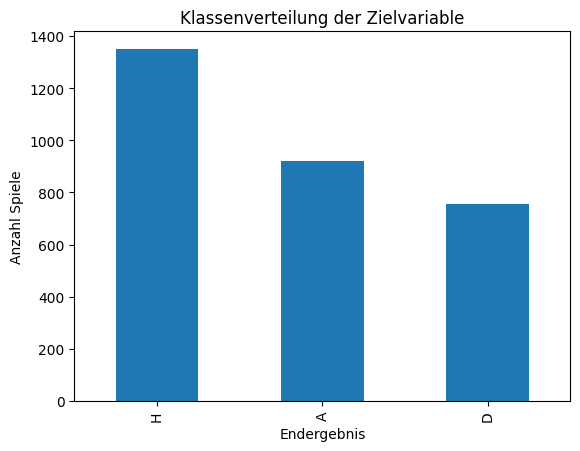

In [4]:
TARGET = "Endergebnis"

print("Klassenverteilung absolut:")
display(df[TARGET].value_counts(dropna=False))

print("Klassenverteilung relativ:")
display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2))

df[TARGET].value_counts().plot(kind="bar")
plt.title("Klassenverteilung der Zielvariable")
plt.xlabel("Endergebnis")
plt.ylabel("Anzahl Spiele")
plt.show()

## 4. Datumsbereinigung

Im Datensatz können Datumswerte mit zweistelligen und vierstelligen Jahreszahlen vorkommen.  
Deshalb wird eine eigene Funktion verwendet, die beide Formate berücksichtigt.

In [5]:
def parse_mixed_german_dates(series: pd.Series) -> pd.Series:
    parsed = pd.to_datetime(series, format="%d/%m/%Y", errors="coerce")
    mask = parsed.isna()
    if mask.any():
        parsed.loc[mask] = pd.to_datetime(series.loc[mask], format="%d/%m/%y", errors="coerce")
    return parsed

df["Datum_parsed"] = parse_mixed_german_dates(df["Datum"])

print("Nicht parsebare Datumswerte:", df["Datum_parsed"].isna().sum())
print("Zeitraum:", df["Datum_parsed"].min(), "bis", df["Datum_parsed"].max())

display(df[["Datum", "Datum_parsed", "Heimmannschaft", "Gastmannschaft", TARGET]].head())

Nicht parsebare Datumswerte: 0
Zeitraum: 2015-08-14 00:00:00 bis 2026-04-19 00:00:00


,Datum,Datum_parsed,Heimmannschaft,Gastmannschaft,Endergebnis
0,22/08/2025,2025-08-22,Bayern Munich,RB Leipzig,H
1,23/08/2025,2025-08-23,Ein Frankfurt,Werder Bremen,H
2,23/08/2025,2025-08-23,Freiburg,Augsburg,A
3,23/08/2025,2025-08-23,Heidenheim,Wolfsburg,A
4,23/08/2025,2025-08-23,Leverkusen,Hoffenheim,A


## 5. Data-Leakage-Abgrenzung

Da `Endergebnis` direkt aus den finalen Toren ableitbar ist, dürfen finale Ergebnisvariablen nicht als Eingabefeatures verwendet werden.

Für die erste Modellstufe werden deshalb ausgeschlossen:
- `Endergebnis`
- `Endergebnis_Heim_Tore`
- `Endergebnis_Gast_Tore`

Teamnamen werden zunächst ebenfalls nicht als Features verwendet, damit das Modell allgemeine Spielmuster lernt und nicht primär Teamidentitäten.

In [6]:
leakage_cols = [
    "Endergebnis",
    "Endergebnis_Heim_Tore",
    "Endergebnis_Gast_Tore",
]

meta_cols = [
    "Liga",
    "Datum",
    "Datum_parsed",
    "Uhrzeit",
    "Heimmannschaft",
    "Gastmannschaft",
]

print("Ausgeschlossene Leakage-Spalten:", [c for c in leakage_cols if c in df.columns])
print("Zunächst ausgeschlossene Meta-Spalten:", [c for c in meta_cols if c in df.columns])

Ausgeschlossene Leakage-Spalten: ['Endergebnis', 'Endergebnis_Heim_Tore', 'Endergebnis_Gast_Tore']
Zunächst ausgeschlossene Meta-Spalten: ['Liga', 'Datum', 'Datum_parsed', 'Uhrzeit', 'Heimmannschaft', 'Gastmannschaft']


## 6. Explorative Datenanalyse der Spielstatistiken

In diesem Abschnitt werden zentrale Spielstatistiken betrachtet.  
Besonders interessant sind Unterschiede zwischen Heim- und Auswärtsteam.

In [7]:
base_stat_cols = [
    "Heim_Schuesse", "Gast_Schuesse",
    "Heim_Schuesse_aufs_Tor", "Gast_Schuesse_aufs_Tor",
    "Heim_Fouls", "Gast_Fouls",
    "Heim_Ecken", "Gast_Ecken",
    "Heim_Gelbe_Karten", "Gast_Gelbe_Karten",
    "Heim_Rote_Karten", "Gast_Rote_Karten",
    "Halbzeit_Heim_Tore", "Halbzeit_Gast_Tore",
]

existing_stat_cols = [c for c in base_stat_cols if c in df.columns]

display(df.groupby(TARGET)[existing_stat_cols].mean().round(2))

,Heim_Schuesse,Gast_Schuesse,Heim_Schuesse_aufs_Tor,Gast_Schuesse_aufs_Tor,Heim_Fouls,Gast_Fouls,Heim_Ecken,Gast_Ecken,Heim_Gelbe_Karten,Gast_Gelbe_Karten,Heim_Rote_Karten,Gast_Rote_Karten,Halbzeit_Heim_Tore,Halbzeit_Gast_Tore
Endergebnis,,,,,,,,,,,,,,
A,12.70,13.36,3.83,5.73,12.25,12.16,5.05,4.63,1.86,1.89,0.10,0.05,0.32,1.13
D,13.69,11.43,4.58,3.96,12.04,12.87,5.36,4.27,1.90,2.12,0.07,0.07,0.55,0.51
H,15.31,10.59,6.39,3.36,11.71,12.45,5.29,4.22,1.59,2.01,0.04,0.11,1.19,0.29


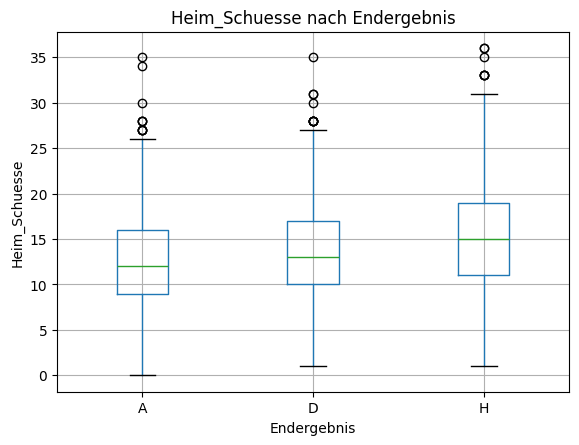

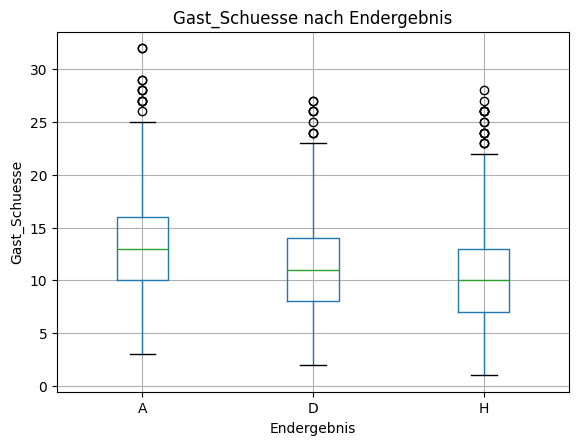

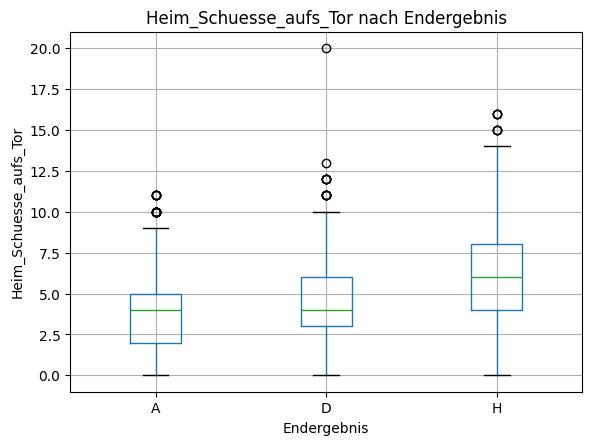

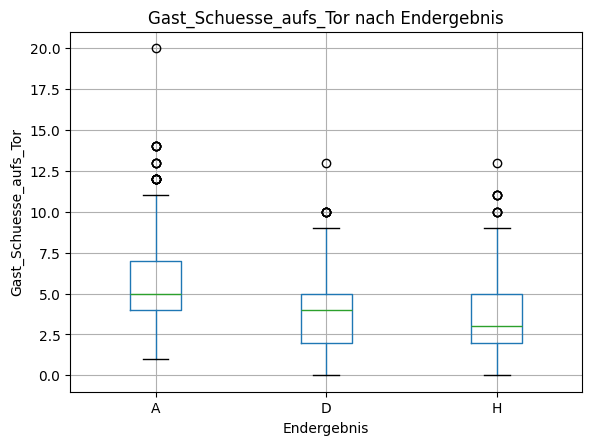

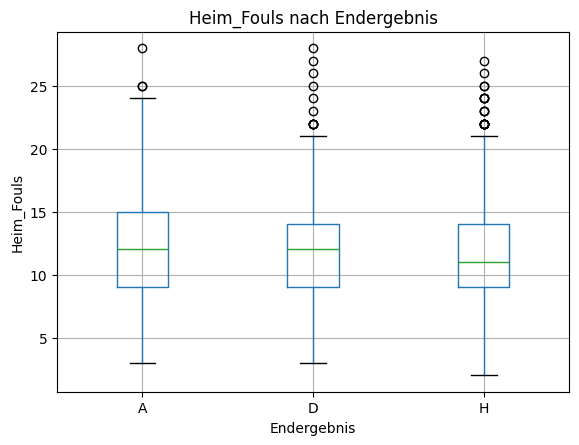

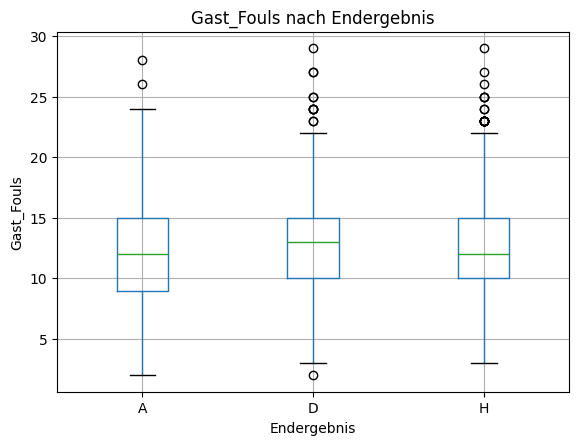

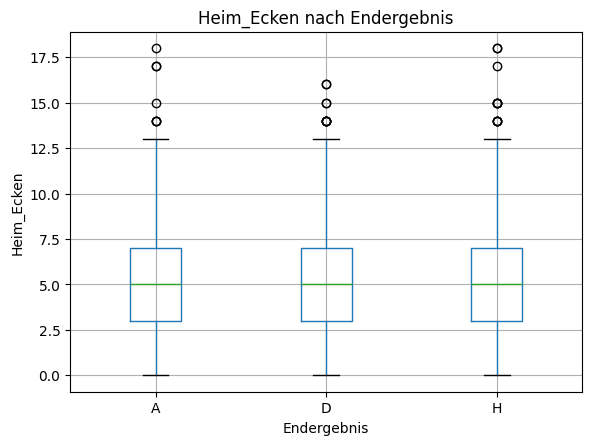

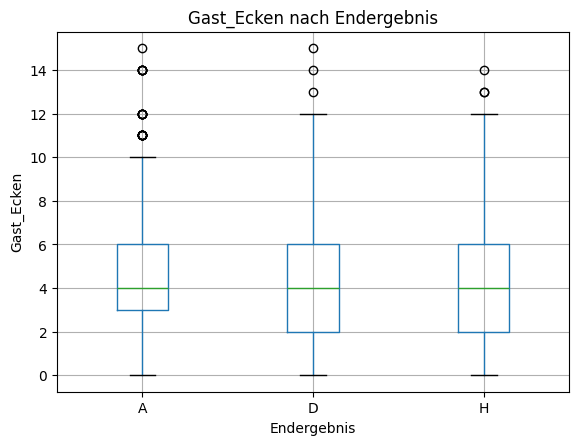

In [8]:
for col in existing_stat_cols[:8]:
    df.boxplot(column=col, by=TARGET)
    plt.title(f"{col} nach Endergebnis")
    plt.suptitle("")
    plt.xlabel("Endergebnis")
    plt.ylabel(col)
    plt.show()

## 7. Feature Engineering

Aus Rohdaten werden neue, interpretierbare Merkmale gebildet.  
Differenzmerkmale sind im Fußball besonders sinnvoll, weil nicht nur die absolute Anzahl einer Aktion relevant ist, sondern der Vergleich zwischen Heim- und Gastteam.

In [9]:
def add_diff_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()

    diff_pairs = {
        "ShotDiff": ("Heim_Schuesse", "Gast_Schuesse"),
        "ShotOnTargetDiff": ("Heim_Schuesse_aufs_Tor", "Gast_Schuesse_aufs_Tor"),
        "FoulDiff": ("Heim_Fouls", "Gast_Fouls"),
        "CornerDiff": ("Heim_Ecken", "Gast_Ecken"),
        "YellowCardDiff": ("Heim_Gelbe_Karten", "Gast_Gelbe_Karten"),
        "RedCardDiff": ("Heim_Rote_Karten", "Gast_Rote_Karten"),
        "HalfTimeGoalDiff": ("Halbzeit_Heim_Tore", "Halbzeit_Gast_Tore"),
    }

    for new_col, (home_col, away_col) in diff_pairs.items():
        if home_col in data.columns and away_col in data.columns:
            data[new_col] = data[home_col] - data[away_col]

    return data

df_fe = add_diff_features(df)

diff_cols = [
    "ShotDiff",
    "ShotOnTargetDiff",
    "FoulDiff",
    "CornerDiff",
    "YellowCardDiff",
    "RedCardDiff",
    "HalfTimeGoalDiff",
]

existing_diff_cols = [c for c in diff_cols if c in df_fe.columns]
display(df_fe[existing_diff_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
ShotDiff,3023.0,2.472378,8.180529,-29.0,-3.0,3.0,8.0,31.0
ShotOnTargetDiff,3023.0,0.933510,3.945259,-18.0,-2.0,1.0,3.0,17.0
FoulDiff,3023.0,-0.512074,5.081640,-24.0,-4.0,0.0,3.0,19.0
CornerDiff,3023.0,0.878267,4.284598,-15.0,-2.0,1.0,4.0,18.0
YellowCardDiff,3023.0,-0.254383,1.679220,-6.0,-1.0,0.0,1.0,6.0
RedCardDiff,3023.0,-0.015217,0.375146,-2.0,0.0,0.0,0.0,3.0
HalfTimeGoalDiff,3023.0,0.166060,1.240268,-6.0,-1.0,0.0,1.0,5.0


,ShotDiff,ShotOnTargetDiff,FoulDiff,CornerDiff,YellowCardDiff,RedCardDiff,HalfTimeGoalDiff
Endergebnis,,,,,,,
A,-0.66,-1.89,0.09,0.43,-0.03,0.06,-0.81
D,2.26,0.62,-0.84,1.09,-0.22,0.00,0.04
H,4.72,3.03,-0.74,1.06,-0.42,-0.07,0.90


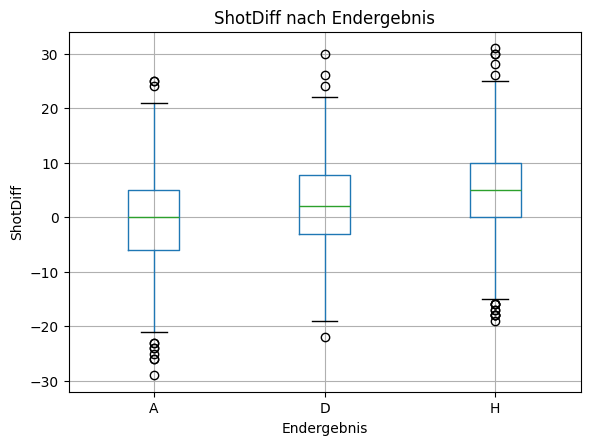

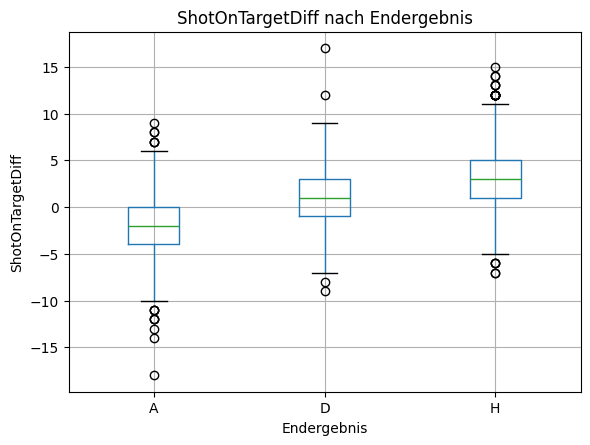

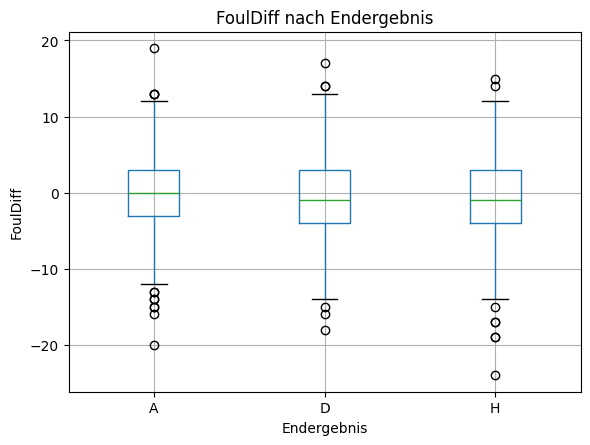

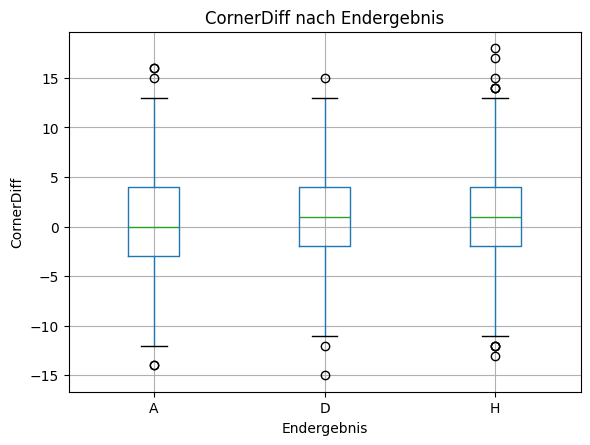

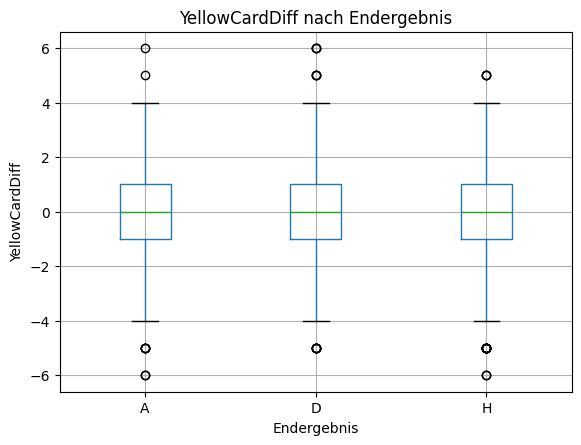

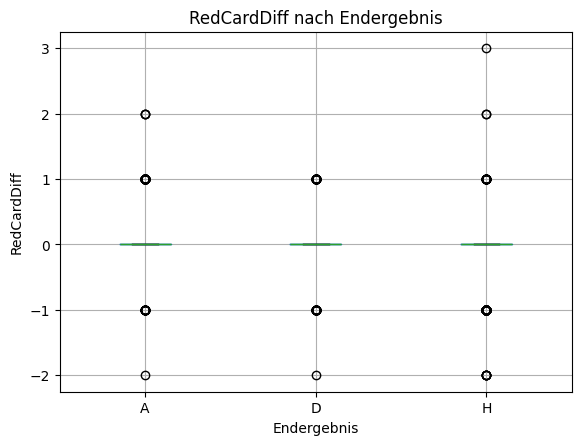

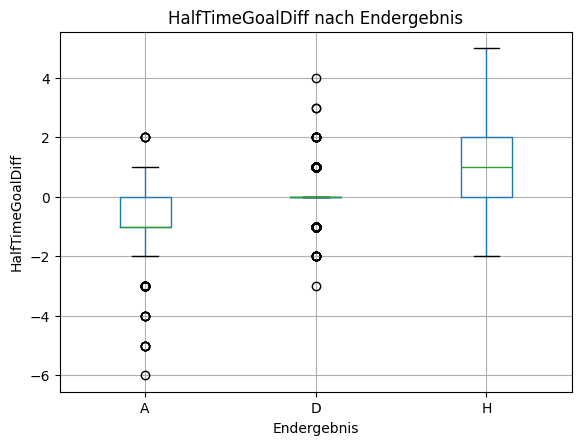

In [10]:
display(df_fe.groupby(TARGET)[existing_diff_cols].mean().round(2))

for col in existing_diff_cols:
    df_fe.boxplot(column=col, by=TARGET)
    plt.title(f"{col} nach Endergebnis")
    plt.suptitle("")
    plt.xlabel("Endergebnis")
    plt.ylabel(col)
    plt.show()

## 8. Feature-Auswahl für Modellstufe 1

Für die erste Modellstufe werden nur gut interpretierbare Post-Game-Features verwendet.  
Wettquoten werden zunächst nicht aufgenommen, weil sie eher eine Pre-Game- bzw. Marktinformation darstellen und eine andere Forschungsfrage eröffnen würden.

In [11]:
numeric_features = [
    "Heim_Schuesse",
    "Gast_Schuesse",
    "Heim_Schuesse_aufs_Tor",
    "Gast_Schuesse_aufs_Tor",
    "Heim_Fouls",
    "Gast_Fouls",
    "Heim_Ecken",
    "Gast_Ecken",
    "Heim_Gelbe_Karten",
    "Gast_Gelbe_Karten",
    "Heim_Rote_Karten",
    "Gast_Rote_Karten",
    "Halbzeit_Heim_Tore",
    "Halbzeit_Gast_Tore",
    "ShotDiff",
    "ShotOnTargetDiff",
    "FoulDiff",
    "CornerDiff",
    "YellowCardDiff",
    "RedCardDiff",
    "HalfTimeGoalDiff",
]

categorical_features = [
    "Halbzeit_Ergebnis",
]

numeric_features = [c for c in numeric_features if c in df_fe.columns]
categorical_features = [c for c in categorical_features if c in df_fe.columns]

feature_cols = numeric_features + categorical_features

print("Numerische Features:")
print(numeric_features)

print("\nKategoriale Features:")
print(categorical_features)

print("\nAnzahl Features vor One-Hot-Encoding:", len(feature_cols))

Numerische Features:
['Heim_Schuesse', 'Gast_Schuesse', 'Heim_Schuesse_aufs_Tor', 'Gast_Schuesse_aufs_Tor', 'Heim_Fouls', 'Gast_Fouls', 'Heim_Ecken', 'Gast_Ecken', 'Heim_Gelbe_Karten', 'Gast_Gelbe_Karten', 'Heim_Rote_Karten', 'Gast_Rote_Karten', 'Halbzeit_Heim_Tore', 'Halbzeit_Gast_Tore', 'ShotDiff', 'ShotOnTargetDiff', 'FoulDiff', 'CornerDiff', 'YellowCardDiff', 'RedCardDiff', 'HalfTimeGoalDiff']

Kategoriale Features:
['Halbzeit_Ergebnis']

Anzahl Features vor One-Hot-Encoding: 22


## 9. Modell-Datensatz erstellen

Zeilen ohne Zielvariable werden ausgeschlossen.  
Fehlende Feature-Werte werden später innerhalb der Pipeline imputiert, damit keine Information aus dem Testset in das Training gelangt.

In [12]:
model_df = df_fe.dropna(subset=[TARGET]).copy()

X = model_df[feature_cols]
y = model_df[TARGET]

print("X:", X.shape)
print("y:", y.shape)
display(y.value_counts())

X: (3024, 22)
y: (3024,)


Endergebnis
H    1350
A     920
D     754
Name: count, dtype: int64

## 10. Train-Test-Split

Die Daten werden in Trainings- und Testdaten getrennt.  
Durch `stratify=y` bleibt die Klassenverteilung in beiden Teilmengen ähnlich.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nKlassenverteilung Training:")
display(y_train.value_counts(normalize=True).round(3))

print("\nKlassenverteilung Test:")
display(y_test.value_counts(normalize=True).round(3))

Train: (2419, 22) (2419,)
Test: (605, 22) (605,)

Klassenverteilung Training:


Endergebnis
H    0.446
A    0.304
D    0.249
Name: proportion, dtype: float64


Klassenverteilung Test:


Endergebnis
H    0.446
A    0.304
D    0.250
Name: proportion, dtype: float64

## 11. Preprocessing-Pipeline

Die Vorverarbeitung wird in einer Pipeline gekapselt:
- numerische Werte: Median-Imputation und Standardisierung
- kategoriale Werte: häufigste Kategorie und One-Hot-Encoding

In [14]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

## 12. Modelle definieren

Es werden drei Modelle verglichen:
1. Dummy Classifier # To Do neues Modell suchen
2. Logistische Regression
3. Random Forest

In [ ]:
models = {
    #Das sollte ersetzt werden durch ein richtiges Modell,
    "Dummy Classifier": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", DummyClassifier(strategy="most_frequent")),
        ]
    ),
    "Logistische Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]
    ),
}

## 13. Training und Evaluation

Die Modelle werden trainiert und anschließend auf dem Testset bewertet.  
Die Hauptmetrik ist `Macro F1`, da sie alle Klassen gleich gewichtet.

In [16]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "Modell": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average="macro"),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted"),
    }

fitted_models = {}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    results.append(evaluate_model(name, model, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("Macro F1", ascending=False)
display(results_df.round(4))

,Modell,Accuracy,Macro F1,Weighted F1
1,Logistische Regression,0.6463,0.6378,0.6584
2,Random Forest,0.6380,0.6124,0.6395
0,Dummy Classifier,0.4463,0.2057,0.2754


## 14. Classification Reports

Die Reports zeigen je Klasse Precision, Recall und F1.  
Besonders wichtig ist, ob die Klasse `D` für Unentschieden ausreichend erkannt wird.

In [17]:
for name, model in fitted_models.items():
    print("=" * 80)
    print(name)
    print("=" * 80)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))

Dummy Classifier
              precision    recall  f1-score   support

           A       0.00      0.00      0.00       184
           D       0.00      0.00      0.00       151
           H       0.45      1.00      0.62       270

    accuracy                           0.45       605
   macro avg       0.15      0.33      0.21       605
weighted avg       0.20      0.45      0.28       605

Logistische Regression
              precision    recall  f1-score   support

           A       0.74      0.68      0.71       184
           D       0.41      0.58      0.48       151
           H       0.80      0.66      0.72       270

    accuracy                           0.65       605
   macro avg       0.65      0.64      0.64       605
weighted avg       0.68      0.65      0.66       605

Random Forest
              precision    recall  f1-score   support

           A       0.70      0.69      0.69       184
           D       0.41      0.42      0.42       151
           H       0.

## 15. Confusion Matrices

Die Confusion Matrix zeigt, welche Klassen häufig verwechselt werden.

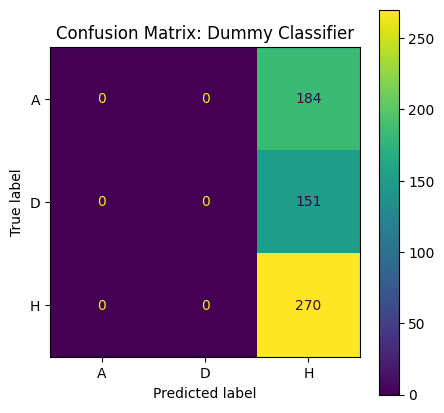

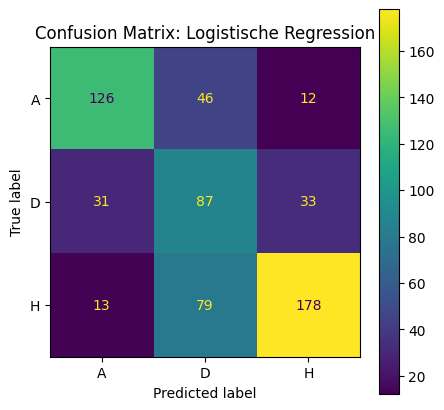

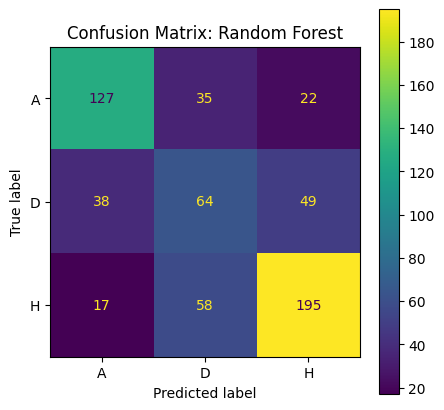

In [18]:
class_labels = sorted(y.unique())

for name, model in fitted_models.items():
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        labels=class_labels,
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix: {name}")
    plt.show()

## 16. Optionale Cross-Validation

Cross-Validation kann genutzt werden, um die Stabilität der Modellleistung besser einzuschätzen.

In [19]:
cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="f1_macro",
        n_jobs=-1,
    )
    cv_results.append({
        "Modell": name,
        "CV Macro F1 Mean": scores.mean(),
        "CV Macro F1 Std": scores.std(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV Macro F1 Mean", ascending=False)
display(cv_results_df.round(4))

,Modell,CV Macro F1 Mean,CV Macro F1 Std
1,Logistische Regression,0.6456,0.0198
2,Random Forest,0.6235,0.0084
0,Dummy Classifier,0.2058,0.0001


## 17. Interpretation der logistischen Regression

Die Koeffizienten der logistischen Regression können Hinweise darauf geben, welche Merkmale mit welchen Ergebnis-Klassen zusammenhängen.  
Positive Koeffizienten erhöhen die Wahrscheinlichkeit der jeweiligen Klasse im Vergleich zu den anderen Klassen.

In [20]:
log_model = fitted_models["Logistische Regression"]
feature_names = log_model.named_steps["preprocessor"].get_feature_names_out()
classes = log_model.named_steps["model"].classes_
coef = log_model.named_steps["model"].coef_

coef_df = pd.DataFrame(coef.T, index=feature_names, columns=classes)
coef_df["MaxAbsCoef"] = coef_df.abs().max(axis=1)

display(coef_df.sort_values("MaxAbsCoef", ascending=False).head(25).round(4))

,A,D,H,MaxAbsCoef
num__HalfTimeGoalDiff,-1.0011,0.1946,0.8066,1.0011
num__ShotOnTargetDiff,-0.5341,0.0040,0.5302,0.5341
num__Gast_Schuesse_aufs_Tor,0.4834,-0.1331,-0.3504,0.4834
num__Heim_Schuesse_aufs_Tor,-0.3502,-0.1127,0.4629,0.4629
num__Halbzeit_Gast_Tore,0.2147,0.1658,-0.3804,0.3804
num__Halbzeit_Heim_Tore,-0.1884,-0.1488,0.3373,0.3373
cat__Halbzeit_Ergebnis_A,-0.1341,-0.1534,0.2875,0.2875
cat__Halbzeit_Ergebnis_D,-0.0766,0.2131,-0.1365,0.2131
num__Gast_Schuesse,-0.1454,0.0917,0.0537,0.1454
cat__Halbzeit_Ergebnis_H,0.1228,0.0099,-0.1327,0.1327


## 18. Feature Importance des Random Forest

Der Random Forest liefert modellinterne Feature Importances.  
Diese sollten vorsichtig interpretiert werden, da korrelierte Merkmale die Wichtigkeiten beeinflussen können.

,Feature,Importance
15,num__ShotOnTargetDiff,0.1090
20,num__HalfTimeGoalDiff,0.0949
21,cat__Halbzeit_Ergebnis_A,0.0585
3,num__Gast_Schuesse_aufs_Tor,0.0582
2,num__Heim_Schuesse_aufs_Tor,0.0577
23,cat__Halbzeit_Ergebnis_H,0.0560
14,num__ShotDiff,0.0513
16,num__FoulDiff,0.0477
0,num__Heim_Schuesse,0.0455
1,num__Gast_Schuesse,0.0443


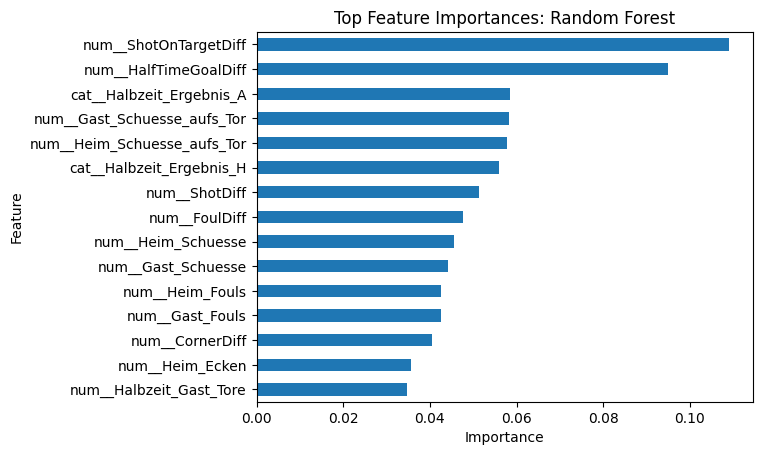

In [21]:
rf_model = fitted_models["Random Forest"]
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model.named_steps["model"].feature_importances_

rf_importance_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
      .sort_values("Importance", ascending=False)
)

display(rf_importance_df.head(25).round(4))

rf_importance_df.head(15).set_index("Feature")["Importance"].sort_values().plot(kind="barh")
plt.title("Top Feature Importances: Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 19. Permutation Importance

Permutation Importance misst, wie stark die Modellleistung sinkt, wenn ein Feature zufällig vertauscht wird.  
Hier wird sie auf den Originalfeatures berechnet und ist deshalb für die Interpretation gut geeignet.

In [22]:
best_model_name = results_df.iloc[0]["Modell"]
best_model = fitted_models[best_model_name]

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_df = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Importance_mean": perm.importances_mean,
        "Importance_std": perm.importances_std,
    })
    .sort_values("Importance_mean", ascending=False)
)

print("Bestes Modell nach Test-Macro-F1:", best_model_name)
display(perm_df.round(4))

Bestes Modell nach Test-Macro-F1: Logistische Regression


,Feature,Importance_mean,Importance_std
20,HalfTimeGoalDiff,0.1155,0.0155
15,ShotOnTargetDiff,0.0473,0.0125
2,Heim_Schuesse_aufs_Tor,0.0434,0.0103
12,Halbzeit_Heim_Tore,0.0354,0.0095
3,Gast_Schuesse_aufs_Tor,0.0296,0.0096
13,Halbzeit_Gast_Tore,0.0140,0.0091
8,Heim_Gelbe_Karten,0.0090,0.0054
4,Heim_Fouls,0.0071,0.0048
1,Gast_Schuesse,0.0059,0.0048
21,Halbzeit_Ergebnis,0.0037,0.0086


## 20. Optionaler Zusatz: Wettquoten als eigener Vergleich

Die Wettquoten können in einem separaten Experiment betrachtet werden.  
Das sollte im Bericht aber klar als andere Perspektive formuliert werden, da Quoten eher Markt- bzw. Pre-Game-Informationen darstellen.

Mögliche Forschungsfrage für diesen Zusatz:
> Verbessern Marktinformationen die Klassifikation gegenüber reinen Post-Game-Spielstatistiken?

In [23]:
odds_keywords = [
    "Markt_Durchschnitt_Heim_Sieg",
    "Markt_Durchschnitt_Unentschieden",
    "Markt_Durchschnitt_Gast_Sieg",
    "Bet365_Heim_Sieg",
    "Bet365_Unentschieden",
    "Bet365_Gast_Sieg",
]

odds_features = [c for c in odds_keywords if c in df_fe.columns]
print("Gefundene Quotenfeatures:", odds_features)

# Dieses Experiment bewusst erst aktivieren, wenn ihr es im Bericht methodisch sauber abgrenzt.
# X_odds = model_df[feature_cols + odds_features]
# Dann analog zu den bisherigen Schritten trainieren und evaluieren.

Gefundene Quotenfeatures: ['Markt_Durchschnitt_Heim_Sieg', 'Markt_Durchschnitt_Unentschieden', 'Markt_Durchschnitt_Gast_Sieg', 'Bet365_Heim_Sieg', 'Bet365_Unentschieden', 'Bet365_Gast_Sieg']


## 21. Kritische Diskussion

Die Ergebnisse sollten im Portfolio nicht nur technisch, sondern auch fachlich interpretiert werden.

Mögliche Diskussionspunkte:

- **Post-Game statt Pre-Game:** Die Modelle erklären abgeschlossene Spiele und sind kein echtes Prognosemodell vor Anpfiff.
- **Data Leakage:** Finale Tore werden ausgeschlossen, weil sie das Ergebnis direkt bestimmen.
- **Klassenproblem:** Unentschieden sind im Fußball häufig schwerer zu erkennen als Siege.
- **Interpretierbarkeit:** Die logistische Regression ist besser erklärbar; der Random Forest kann dafür nicht-lineare Muster erfassen.
- **Datenqualität:** Fehlende Werte und stark lückenhafte Quotenanbieter-Spalten müssen dokumentiert werden.
- **Erweiterung:** Für eine echte Pre-Game-Prognose müssten ausschließlich vor Spielbeginn bekannte Variablen genutzt werden, z. B. Tabellenposition, Formkurve, Verletzungen, Marktquoten oder historische Teamstärke.

## 22. Fazit-Vorlage

In diesem Projekt wurde ein Machine-Learning-Workflow zur Post-Game-Analyse von Fußballspielen umgesetzt. Die Zielvariable war das dreiklassige Endergebnis (`H`, `D`, `A`). Nach einer explorativen Datenanalyse wurden zentrale Differenzmerkmale gebildet und mehrere Klassifikationsmodelle miteinander verglichen.

Die Ergebnisse zeigen, welches Modell die beste Balance zwischen Genauigkeit und klassenfairer Bewertung erreicht. Besonders relevant ist dabei der Macro-F1-Wert, da er auch die schwächer vertretenen Klassen berücksichtigt. Die Feature-Interpretation liefert Hinweise darauf, welche Spielstatistiken am stärksten mit Heimsieg, Unentschieden oder Auswärtssieg zusammenhängen.

Für eine mögliche Weiterentwicklung wäre eine echte Pre-Game-Prognose interessant. Dafür müsste jedoch ein anderer Feature-Satz verwendet werden, der ausschließlich vor Spielbeginn verfügbare Informationen enthält.